<a href="https://colab.research.google.com/github/thigas77-bit/neuronio-artificial-sigmoid/blob/main/Sigmoid_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

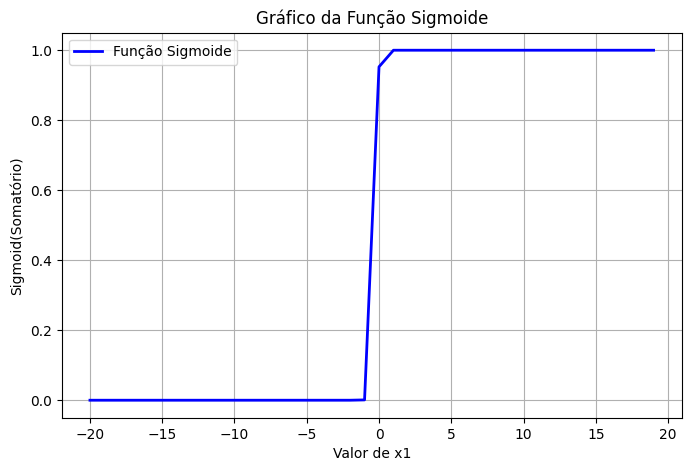

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


listax = []
listay = []

for i in range(-20, 20):
    x1 = i
    x2 = 0
    x3 = 0

    w1 = 10
    w2 = 10
    w3 = -2

    b = 3

    calculo1 = w1 * x1
    calculo2 = w2 * x2
    calculo3 = w3 * x3

    somatorio = calculo1 + calculo2 + calculo3 + b

    conclusao = 1 / (1 + math.e ** (-somatorio))


    listax.append(i)         # Eixo X: o valor de entrada que está variando
    listay.append(conclusao)   # Eixo Y: o resultado da função de ativação

#  Bloco do Gráfico
plt.figure(figsize=(8, 5))

# Agora listax e listay existem e possuem os dados coletados no loop!
plt.plot(listax, listay, color='blue', linewidth=2, label='Função Sigmoide')

plt.title('Gráfico da Função Sigmoide')
plt.xlabel('Valor de x1')
plt.ylabel('Sigmoid(Somatório)')
plt.grid(True)
plt.legend()
plt.show()

In [2]:
# 1. Função de Ativação Sigmoide e sua Derivada (como no slide)
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def sigmoide_derivada(y_predito):
    # A derivada da sigmoide expressa em função do próprio resultado dela
    return y_predito * (1 - y_predito)

# 2. Dados de Treinamento Simples
# Entradas (X) e a Saída Desejada (Y)
X_treino = np.array([2.0, 4.0, 6.0])
y_treino = np.array([0.2, 0.5, 0.8])

# 3. Inicialização dos Parâmetros (valores parecidos com os seus testes)
w = 0.5      # Peso inicial
b = 0.1      # Viés (bias) inicial
eta = 0.1    # Taxa de aprendizado (o 'n' do seu código anterior)
epocas = 1000

print(" Treinando o Perceptron\n")

# 4. Loop de Treinamento
for epoca in range(epocas):
    for x, y_real in zip(X_treino, y_treino):

        # Passo 1: Forward (Avanço) - Calcula a saída do neurônio
        z = (x * w) + b
        y_predito = sigmoide(z)

        # Passo 2: Calcular o Erro Linear
        erro = y_real - y_predito

        # Passo 3: Calcular o Gradiente Local (Erro * Derivada da Ativação)
        # É isso que direciona o ajuste de forma suave
        delta = erro * sigmoide_derivada(y_predito)

        # Passo 4: Backward (Ajuste dos pesos e viés)
        w = w + (eta * delta * x)
        b = b + (eta * delta)

    # Mostra o progresso a cada 200 épocas
    if (epoca + 1) % 200 == 0:
        print(f"Época {epoca+1:4d} | Peso (w): {w:.4f} | Viés (b): {b:.4f} | Último Erro: {erro:.4f}")

print("\n Treinamento concluído!")

# 5. Teste Prático
print("\n=== Teste de Validação ===")
for x, y_real in zip(X_treino, y_treino):
    resultado = sigmoide((x * w) + b)
    print(f"Para X = {x} | Esperado: {y_real} -> Neurônio previu: {resultado:.2f}")

 Treinando o Perceptron com as regras do slide...

Época  200 | Peso (w): 0.3020 | Viés (b): -0.9659 | Último Erro: 0.1212
Época  400 | Peso (w): 0.4232 | Viés (b): -1.5356 | Último Erro: 0.0802
Época  600 | Peso (w): 0.4988 | Viés (b): -1.8863 | Último Erro: 0.0559
Época  800 | Peso (w): 0.5492 | Viés (b): -2.1178 | Último Erro: 0.0405
Época 1000 | Peso (w): 0.5843 | Viés (b): -2.2787 | Último Erro: 0.0301

 Treinamento concluído!

=== Teste de Validação ===
Para X = 2.0 | Esperado: 0.2 -> Neurônio previu: 0.25
Para X = 4.0 | Esperado: 0.5 -> Neurônio previu: 0.51
Para X = 6.0 | Esperado: 0.8 -> Neurônio previu: 0.77
